In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
import statsmodels.api as sm
import numpy as np


In [ ]:
file_path = "/content/drive/MyDrive/Analisis matemático/FINALMODELOajustelocal.csv"
df_modelo = pd.read_csv(file_path, encoding='latin1')

In [ ]:
df_modelo["LOG_POBLACION_TOTAL"] = np.log(df_modelo["POBLACION_TOTAL"].replace(0, np.nan))
df_modelo["LOG_POBLACION_20_24"] = np.log(df_modelo["POBLACION_20_24"].replace(0, np.nan))


In [ ]:
df_modelo

,COUNTRY,YEAR,POBLACION_0_14,POBLACION_TOTAL,PIB_POR_PAIS,TASA_MORTALIDAD_INFANTIL,POBLACION_20_24_VARONES,POBLACION_20_24_MUJERES,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,MEDALLAS_DE_ORO_TOTALES_POR_PAIS_POR_AÑO,...,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS,BOICOT_1980,BOICOT_1984,DUMMY_AUSTRALIA,DUMMY_UK,DUMMY_CHINA_MODERNA,DUMMY_FRANCE,LOG_POBLACION_TOTAL,LOG_POBLACION_20_24
0,Afghanistan,2008,13043065,26482622.0,381.733238,69.6,8.50,8.33,1,0,...,2.871497,1.871497,0,0,0,0,0,0,17.091999,15.309992
1,Afghanistan,2012,14548198,30560034.0,651.417134,60.1,9.06,8.89,1,0,...,2.942766,1.942766,0,0,0,0,0,0,17.235204,15.517624
2,Albania,2024,467968,2745972.0,8575.171134,8.4,7.40,6.80,2,0,...,6.640047,4.640047,0,0,0,0,0,0,14.825646,12.873717
3,Algeria,1984,9580584,21271969.0,2524.380714,67.7,9.51,9.02,2,0,...,3.328880,1.328881,0,1,0,0,0,0,16.872901,15.187122
4,Algeria,1992,10910578,26628568.0,1802.693008,42.1,9.95,9.53,2,1,...,4.585902,2.585902,0,0,0,0,0,0,17.097495,15.461713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054,Zambia,1996,4343670,9004053.0,399.511305,100.3,9.72,9.46,1,0,...,2.032876,1.032876,0,0,0,0,0,0,16.013185,14.361883
1055,Zambia,2024,8694765,20723965.0,1330.727806,40.9,9.41,9.37,1,0,...,4.056975,3.056975,0,0,0,0,0,0,16.846801,15.174424
1056,Zimbabwe,1980,3428620,7041303.0,948.527311,70.5,7.87,9.40,15,15,...,3.164395,11.835605,1,0,0,0,0,0,15.767304,14.011105
1057,Zimbabwe,2004,5154172,12365896.0,469.484654,51.6,11.68,12.62,3,1,...,3.655562,0.655562,0,0,0,0,0,0,16.330453,14.915759


In [ ]:
# 1. Crear nuevos dummies

# China moderna (año >= 2000)
df_modelo["DUMMY_CHINA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "China" and row["YEAR"] >= 2008 else 0, axis=1)
df_modelo["DUMMY_KOREA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "South Korea" and row["YEAR"] >= 1988 else 0, axis=1)

# Francia (en general)
df_modelo["DUMMY_FRANCE"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "France" else 0)
df_modelo["DUMMY_ITALY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Italy" else 0)
df_modelo["DUMMY_HUNGARY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Hungary" else 0)
df_modelo["DUMMY_JAPAN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Japan" else 0)
df_modelo["DUMMY_BULGARIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Bulgaria" else 0)
df_modelo["DUMMY_CUBA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Cuba" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_ROMANIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Romania" else 0)
df_modelo["DUMMY_SPAIN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Spain" else 0)
df_modelo["DUMMY_SERBIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Serbia" else 0)
df_modelo["DUMMY_CANADA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Canada" else 0)
df_modelo["DUMMY_BRAZIL"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Brazil" else 0)
df_modelo["DUMMY_POLAND"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Poland" else 0)
# 2. Redefinir X con las nuevas variables
X = df_modelo[[
    "PIB_REAL",
    "LOG_POBLACION_TOTAL",
    "LOG_POBLACION_20_24",
    "TASA_MORTALIDAD_INFANTIL_CENTRADO",
    "LOCAL",
    "VECINO",
   "DUMMY_CHINA_MODERNA",
    "DUMMY_RUSSIA",
    "DUMMY_USA",
    "DUMMY_GERMANY",
   # "BOICOT_1980",
   # "BOICOT_1984",
    "DUMMY_AUSTRALIA",
    "DUMMY_UK",
    "DUMMY_FRANCE",
    "DUMMY_ITALY",
    "DUMMY_HUNGARY",
    "DUMMY_JAPAN",
    "DUMMY_BULGARIA",
    "DUMMY_CUBA",
    "DUMMY_KOREA_MODERNA",
    "DUMMY_NETHERLANDS",
    "DUMMY_ROMANIA",
    "DUMMY_SPAIN",
   "DUMMY_SERBIA",
    "DUMMY_CANADA",
    "DUMMY_BRAZIL",
    "DUMMY_POLAND"

]]

# 3. Agregar constante
X = sm.add_constant(X)

# 4. Definir y
y= df_modelo["LOG_PROP_MEDALLAS"]

# 5. Ajustar el modelo
modelo = sm.OLS(y, X).fit()

# 6. Mostrar el resumen del modelo
print(modelo.summary())



                            OLS Regression Results                            
Dep. Variable:      LOG_PROP_MEDALLAS   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     71.49
Date:                Fri, 02 May 2025   Prob (F-statistic):          6.57e-210
Time:                        16:26:55   Log-Likelihood:                -1440.3
No. Observations:                1059   AIC:                             2935.
Df Residuals:                    1032   BIC:                             3069.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [ ]:
import numpy as np

# 1. Predecir log(ŵ_it) con el modelo
log_predicciones = modelo.predict(X)

# 2. Destransformar: volver a escala real (ŵ_it)
predicciones = np.exp(log_predicciones)

# 3. Agregar las predicciones al dataframe de modelado
df_modelo["PROP_MEDALLAS_PREDICHA"] = predicciones

# 4. Opcional: calcular error absoluto entre proporción real y predicha
df_modelo["ERROR_ABSOLUTO"] = np.abs(df_modelo["PROP_MEDALLAS"] - df_modelo["PROP_MEDALLAS_PREDICHA"])

# 5. Mostrar ejemplo de tabla de resultados
resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_TOTALES_POR_PAIS_POR_AÑO",
    "PROP_MEDALLAS",
    "PROP_MEDALLAS_PREDICHA",
    "ERROR_ABSOLUTO"
]].sort_values(by="ERROR_ABSOLUTO", ascending=False)

# Mostrar los 10 países con mayor error
resultados.head(10)


,COUNTRY,YEAR,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,PROP_MEDALLAS,PROP_MEDALLAS_PREDICHA,ERROR_ABSOLUTO
797,Russia,1980,442,0.319134,0.114755,0.204379
1019,United States,1984,352,0.238644,0.121521,0.117123
354,Germany,1976,273,0.206818,0.094475,0.112343
353,Germany,1972,253,0.208230,0.096706,0.111525
357,Germany,1988,296,0.187223,0.083001,0.104223
796,Russia,1976,286,0.216667,0.118762,0.097904
355,Germany,1980,264,0.190614,0.095013,0.095601
805,Russia,2016,115,0.057072,0.136452,0.079380
792,Russia,1960,169,0.185919,0.111624,0.074294
366,Germany,2024,108,0.047682,0.121738,0.074056


In [ ]:
# 1. Primero, recuperar el total de medallas entregadas cada año
total_medallas_por_ano = df_modelo.groupby("YEAR")["MEDALLAS_TOTALES_POR_PAIS_POR_AÑO"].transform("sum")

# 2. Calcular las medallas reales y predichas en números absolutos
df_modelo["MEDALLAS_REALES"] = df_modelo["PROP_MEDALLAS"] * total_medallas_por_ano
df_modelo["MEDALLAS_PREDICHAS"] = df_modelo["PROP_MEDALLAS_PREDICHA"] * total_medallas_por_ano

# 3. Calcular error absoluto en número de medallas
df_modelo["ERROR_ABSOLUTO_MEDALLAS"] = np.abs(df_modelo["MEDALLAS_REALES"] - df_modelo["MEDALLAS_PREDICHAS"])

# 4. Armar la tabla ordenada
tabla_resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_REALES",
    "MEDALLAS_PREDICHAS",
    "ERROR_ABSOLUTO_MEDALLAS"
]].sort_values(by="ERROR_ABSOLUTO_MEDALLAS", ascending=False)

# 5. Mostrar los 10 países con mayor error absoluto
tabla_resultados.head(15)


,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
797,Russia,1980,442.000000,158.935496,283.064504
1019,United States,1984,352.000000,179.243336,172.756665
366,Germany,2024,108.000000,275.736338,167.736339
357,Germany,1988,295.999999,131.224074,164.775926
805,Russia,2016,114.999999,274.950417,159.950418
354,Germany,1976,273.000000,124.707415,148.292586
365,Germany,2020,81.000000,223.387724,142.387724
353,Germany,1972,253.000000,117.497670,135.502331
355,Germany,1980,263.999999,131.592373,132.407626
796,Russia,1976,286.000000,156.766141,129.233859


In [ ]:
tabla_resultados.to_excel(".xlsx", index=False)

In [ ]:
df=tabla_resultados

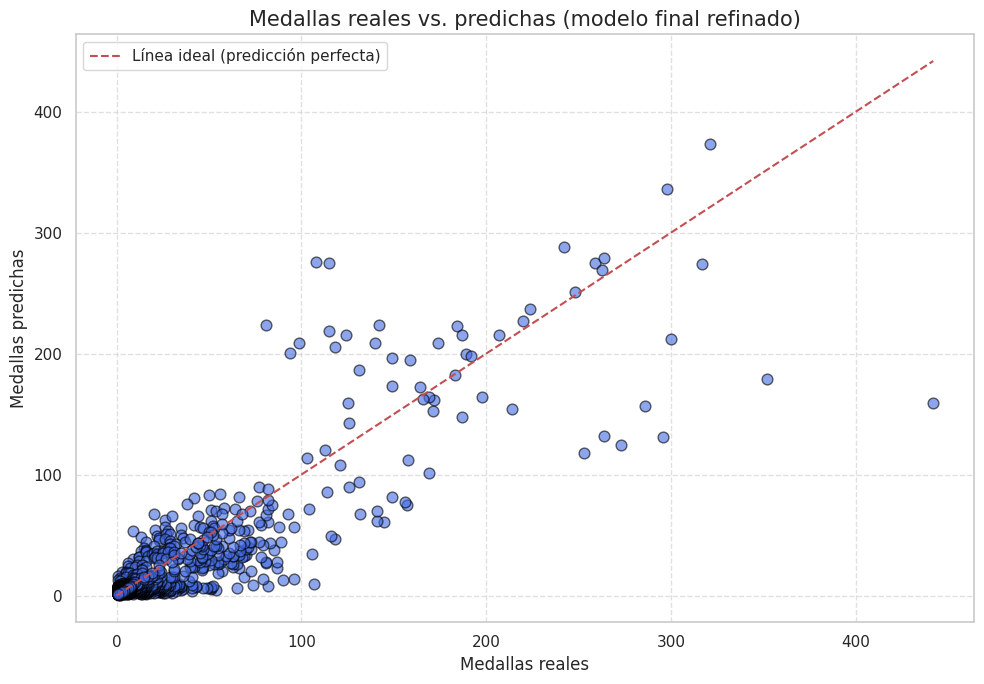

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar archivo de resultados
#df = pd.read_excel("RESULTADOS5.xlsx")  # Asegúrate de tener este archivo en tu carpeta de trabajo

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# 3. Seleccionar las columnas necesarias y eliminar valores nulos
df_grafico = df[["COUNTRY", "YEAR", "MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].dropna()

# 4. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_grafico["MEDALLAS_REALES"],
    df_grafico["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='royalblue',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, df_grafico["MEDALLAS_REALES"].max()],
    [0, df_grafico["MEDALLAS_REALES"].max()],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 5. Etiquetas y formato
plt.title("Medallas reales vs. predichas (modelo final refinado)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Mostrar
plt.show()


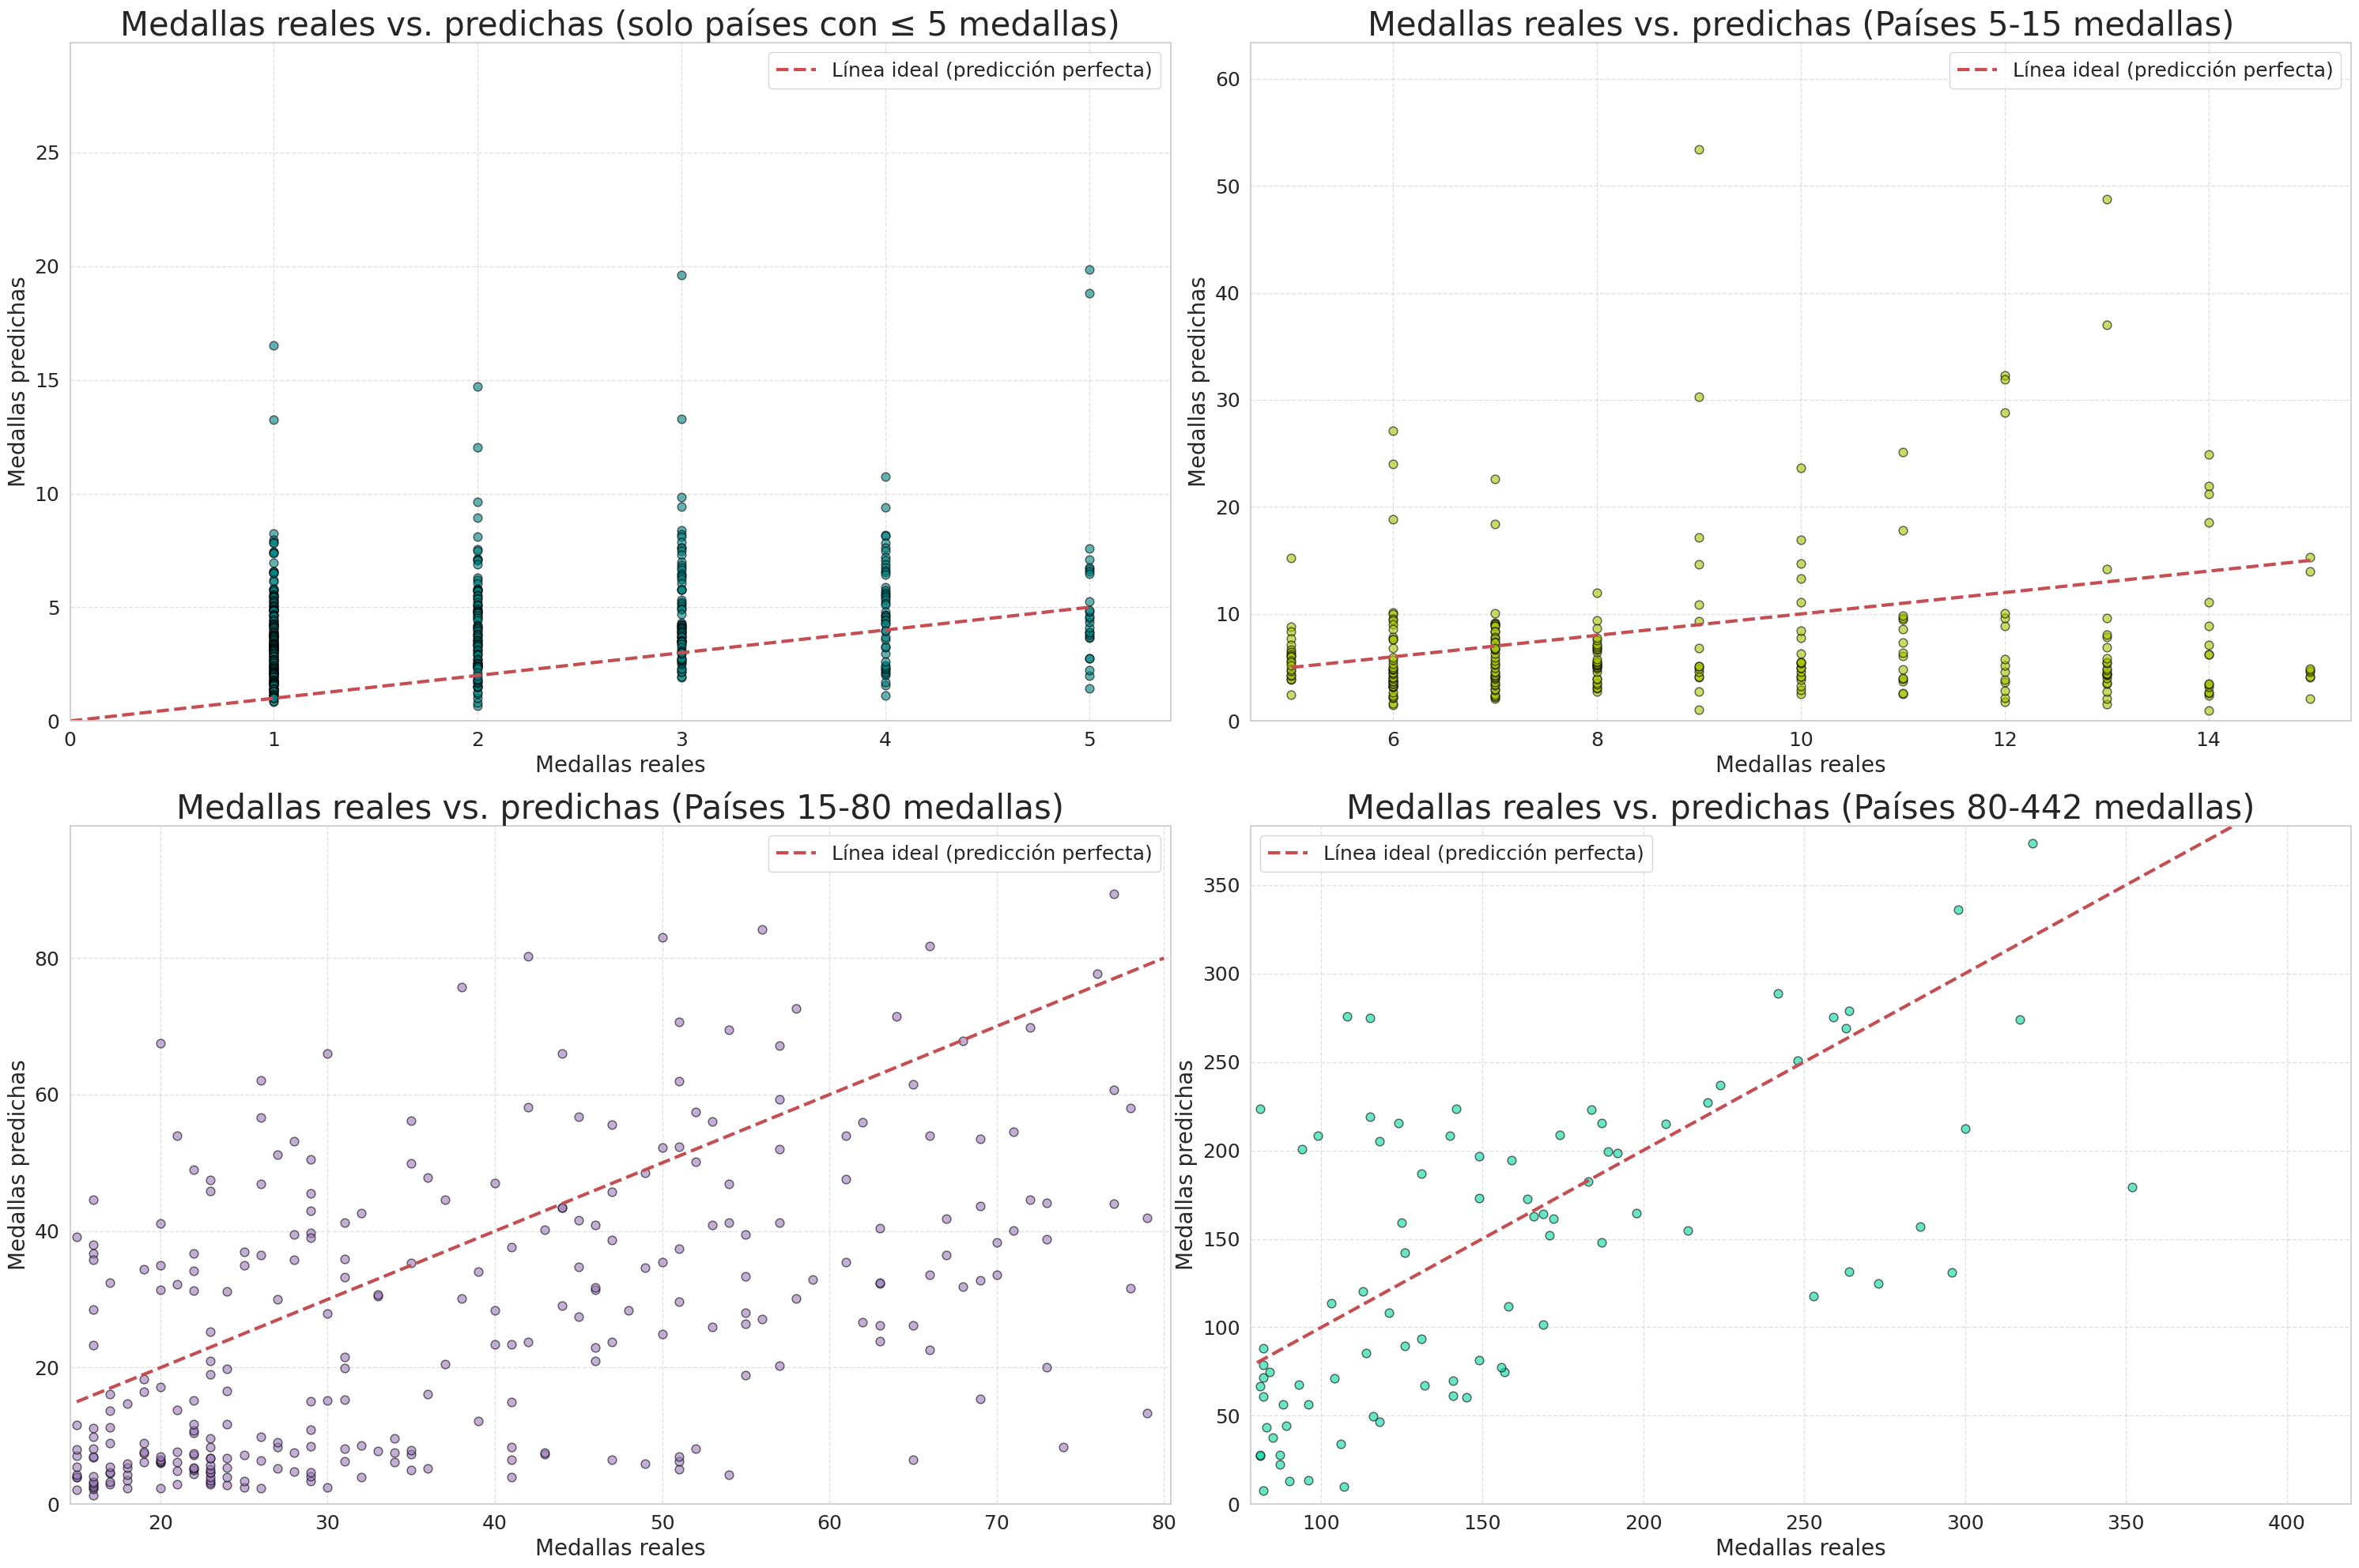

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar datos
df.columns = df.columns.str.strip()

# 2. Filtrar solo países con hasta 100 medallas reales
df_sub = df[df["MEDALLAS_REALES"] <= 5].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Crear gráfico
plt.figure(figsize=(30, 20))
plt.subplot(2,2,1)
plt.scatter(
    df_sub["MEDALLAS_REALES"],
    df_sub["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='teal',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, 5],
    [0, 5],
    'r--',
    label='Línea ideal (predicción perfecta)',
    linewidth=3
)

# 4. Etiquetas y formato
plt.title("Medallas reales vs. predichas (solo países con ≤ 5 medallas)", fontsize=30)
plt.xlabel("Medallas reales", fontsize=20)
plt.ylabel("Medallas predichas", fontsize=20)
plt.xlim(0, 5.4)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(prop={'size': 18})  # Adjust the font size here
plt.tick_params(axis='both', labelsize=18)
# 5. Mostrar

############################################################
# 2. Filtrar solo países con hasta 100 medallas reales
df_sub = df[(df["MEDALLAS_REALES"] <= 15) & (df["MEDALLAS_REALES"] > 5)].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Crear gráfico
plt.subplot(2,2,2)
plt.scatter(
    df_sub["MEDALLAS_REALES"],
    df_sub["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color="#A4C400",
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [5, 15],
    [5, 15],
    'r--',
    label='Línea ideal (predicción perfecta)',
    linewidth=3
)

# 4. Etiquetas y formato
plt.title("Medallas reales vs. predichas (Países 5-15 medallas)", fontsize=30)
plt.xlabel("Medallas reales", fontsize=20)
plt.ylabel("Medallas predichas", fontsize=20)
plt.xlim(4.6, 15.4)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(prop={'size': 18})  # Adjust the font size here
plt.tick_params(axis='both', labelsize=18) # 2. Filtrar solo países con hasta 100 medallas reales

##############################################################################################################################
df_sub = df[(df["MEDALLAS_REALES"] <= 80) & (df["MEDALLAS_REALES"] > 15)].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Crear gráfico
plt.subplot(2,2,3)
plt.scatter(
    df_sub["MEDALLAS_REALES"],
    df_sub["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color="#9D79BC",
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [15, 80],
    [15, 80],
    'r--',
    label='Línea ideal (predicción perfecta)',
    linewidth=3
)

# 4. Etiquetas y formato
plt.title("Medallas reales vs. predichas (Países 15-80 medallas)", fontsize=30)
plt.xlabel("Medallas reales", fontsize=20)
plt.ylabel("Medallas predichas", fontsize=20)
plt.xlim(14.6, 80.4)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(prop={'size': 18})  # Adjust the font size here
plt.tick_params(axis='both', labelsize=18)
##############################################################################################################################
df_sub = df[(df["MEDALLAS_REALES"] <= 500) & (df["MEDALLAS_REALES"] > 80)].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Crear gráfico
plt.subplot(2,2,4)
plt.scatter(
    df_sub["MEDALLAS_REALES"],
    df_sub["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color="#06D6A0",
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [80, 450],
    [80, 450],
    'r--',
    label='Línea ideal (predicción perfecta)',
    linewidth=3
)

# 4. Etiquetas y formato
plt.title("Medallas reales vs. predichas (Países 80-442 medallas)", fontsize=30)
plt.xlabel("Medallas reales", fontsize=20)
plt.ylabel("Medallas predichas", fontsize=20)
plt.xlim(78, 420)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(prop={'size': 18})  # Adjust the font size here
plt.tick_params(axis='both', labelsize=18)
#plt.suptitle("Medallas reales por año vs. predichas por año (modelo final refinado)", fontsize=25)
# 5. Mostrar
plt.show()


In [ ]:
import pandas as pd

# 1. Cargar archivo de resultados
df.columns = df.columns.str.strip()

# 2. Agrupar por país y sumar medallas reales y predichas
tabla_resumen = df.groupby("COUNTRY")[["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].sum().reset_index()

# 3. Calcular el error absoluto total por país
tabla_resumen["ERROR_ABSOLUTO_TOTAL"] = abs(tabla_resumen["MEDALLAS_REALES"] - tabla_resumen["MEDALLAS_PREDICHAS"])

# 4. Renombrar columnas para claridad
tabla_resumen.columns = ["COUNTRY", "MEDALLAS_REALES_TOTALES", "MEDALLAS_PREDICHAS_TOTALES", "ERROR_ABSOLUTO_TOTAL"]

# 5. Ordenar por error total (opcional: puedes cambiar a orden por medallas reales si lo prefieres)
tabla_resumen = tabla_resumen.sort_values("ERROR_ABSOLUTO_TOTAL", ascending=False)

# 6. Mostrar las primeras filas
print(tabla_resumen.head(15))

# (Opcional) Guardar a Excel
tabla_resumen.to_excel("resumen_medallas_totales_con_errores.xlsx", index=False)


            COUNTRY  MEDALLAS_REALES_TOTALES  MEDALLAS_PREDICHAS_TOTALES  \
24            China              1234.000000                  828.083002   
83      New Zealand               330.000001                   72.811564   
112          Sweden               350.000001                  121.368805   
32          Denmark               329.999996                  101.911920   
82      Netherlands               789.000000                  562.948148   
31   Czech Republic               310.999999                   90.768942   
6         Australia              1410.000002                 1196.187818   
108           Spain               606.999997                  415.105463   
3         Argentina               266.000002                   74.184591   
125         Ukraine               233.000002                   64.276776   
43           France              1047.000001                  888.275563   
127  United Kingdom              1143.999998                  991.351340   
88          

In [ ]:
filtered_tabla = tabla_resultados[tabla_resultados['MEDALLAS_REALES'] > 0].sort_values(by='MEDALLAS_REALES', ascending=False)
filtered_tabla
filtered_tabla.to_excel("añoaño.xlsx", index=False)

In [ ]:
tabla_resumen = tabla_resumen[tabla_resumen['MEDALLAS_REALES_TOTALES'] > 75].sort_values(by='ERROR_ABSOLUTO_TOTAL', ascending=True).head(15)
tabla_resumen

,COUNTRY,MEDALLAS_REALES_TOTALES,MEDALLAS_PREDICHAS_TOTALES,ERROR_ABSOLUTO_TOTAL
42,Finland,87.000001,87.839028,0.839027
13,Belgium,113.000001,114.170603,1.170601
128,United States,3790.000000,3788.667290,1.332710
52,Hungary,780.999999,772.575886,8.424112
75,Mexico,112.000002,95.967598,16.032404
48,Greece,115.999997,95.572000,20.427997
122,Turkey,94.999996,70.803967,24.196029
113,Switzerland,156.000001,130.640302,25.359699
46,Germany,2682.000002,2709.055005,27.055003
60,Italy,982.000000,951.296432,30.703568


In [ ]:
import pandas as pd

# Cargar la base de datos proporcionada (simulada aquí como ejemplo)
# En práctica, esta línea se sustituye con la carga real de `tabla_resumen`


# Definir los rangos de medallas reales totales
def clasificar_rango(medallas):
    if medallas > 247:
        return '> 247'
    elif 46 < medallas <= 247:
        return '46 – 247'
    elif 14 < medallas <= 46:
        return '14 – 46'
    elif 2 < medallas <= 14:
        return '2 – 14'
    else:
        return '< 2'

tabla_resumen['RANGO'] = tabla_resumen['MEDALLAS_REALES_TOTALES'].apply(clasificar_rango)

# Agrupar por rango y resumir
resumen_cuartiles = tabla_resumen.groupby('RANGO').agg(
    NUM_PAISES=('COUNTRY', 'count'),
    ERROR_PROMEDIO=('ERROR_ABSOLUTO_TOTAL', 'mean'),
    PAIS_EJEMPLO=('COUNTRY', 'first')
).reset_index()

resumen_cuartiles.sort_values(by='ERROR_PROMEDIO', ascending=False, inplace=True)

resumen_cuartiles


,RANGO,NUM_PAISES,ERROR_PROMEDIO,PAIS_EJEMPLO
4,> 247,26,137.867264,China
2,46 – 247,27,44.310164,Ukraine
0,14 – 46,26,13.813640,Portugal
1,2 – 14,28,7.401051,Philippines
3,< 2,28,1.834855,Cyprus


In [ ]:
import pandas as pd

# Clasificación de rangos de medallas reales
def clasificar_rango(medallas):
    if medallas > 247:
        return '> 247'
    elif 46 < medallas <= 247:
        return '46 – 247'
    elif 14 < medallas <= 46:
        return '14 – 46'
    elif 2 < medallas <= 14:
        return '2 – 14'
    else:
        return '< 2'

# Asignar rango
tabla_resumen['RANGO'] = tabla_resumen['MEDALLAS_REALES_TOTALES'].apply(clasificar_rango)

# Calcular error porcentual individual
tabla_resumen['ERROR_PORCENTAJE'] = (
    tabla_resumen['ERROR_ABSOLUTO_TOTAL'] / tabla_resumen['MEDALLAS_REALES_TOTALES']
) * 100

# Agrupar por rango y calcular resumen
resumen_cuartiles = tabla_resumen.groupby('RANGO').agg(
    NUM_PAISES=('COUNTRY', 'count'),
    ERROR_PROMEDIO=('ERROR_ABSOLUTO_TOTAL', 'mean'),
    ERROR_PORCENTAJE_PROMEDIO=('ERROR_PORCENTAJE', 'mean'),
    PAIS_EJEMPLO=('COUNTRY', 'first')
).reset_index()

# Ordenar por rango (opcional)
resumen_cuartiles = resumen_cuartiles.sort_values(by='ERROR_PROMEDIO', ascending=False)

# Mostrar tabla
resumen_cuartiles


,RANGO,NUM_PAISES,ERROR_PROMEDIO,ERROR_PORCENTAJE_PROMEDIO,PAIS_EJEMPLO
4,> 247,26,137.867264,27.329960,China
2,46 – 247,27,44.310164,41.147990,Ukraine
0,14 – 46,26,13.813640,52.139164,Portugal
1,2 – 14,28,7.401051,130.887894,Philippines
3,< 2,28,1.834855,131.195616,Cyprus


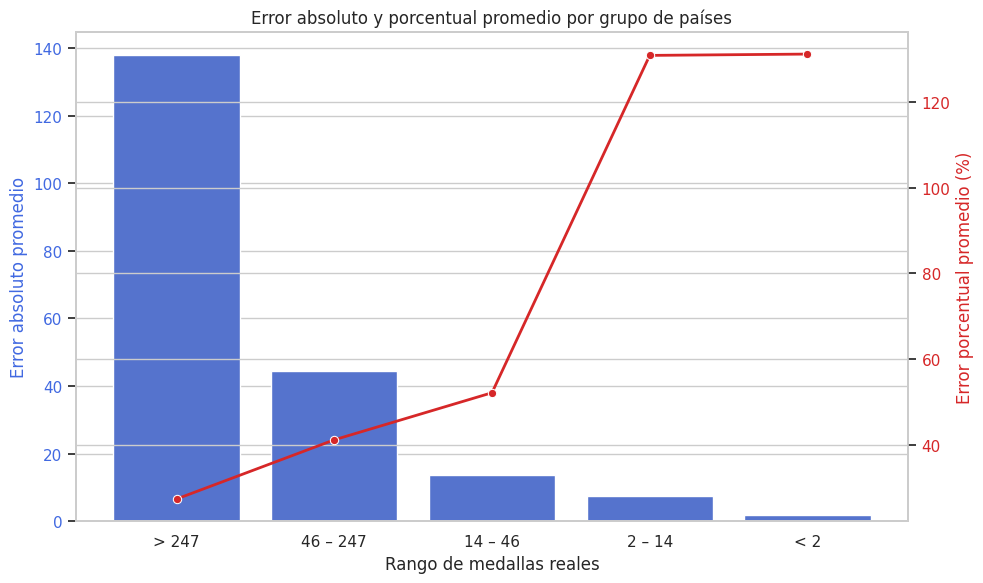

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de que 'resumen_cuartiles' ya contiene los datos agrupados

# Configuración estética
sns.set(style="whitegrid")

# Crear figura y ejes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfica de barras para error absoluto
#color = 'tab:navy'
sns.barplot(x='RANGO', y='ERROR_PROMEDIO', data=resumen_cuartiles, ax=ax1, color="royalblue")
ax1.set_ylabel('Error absoluto promedio', color="royalblue")
ax1.set_xlabel('Rango de medallas reales')
ax1.tick_params(axis='y', labelcolor="royalblue")

# Crear segundo eje y para error porcentual
ax2 = ax1.twinx()
color = 'tab:red'
sns.lineplot(x='RANGO', y='ERROR_PORCENTAJE_PROMEDIO', data=resumen_cuartiles, ax=ax2, color=color, marker='o', linewidth=2)
ax2.set_ylabel('Error porcentual promedio (%)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Título
plt.title('Error absoluto y porcentual promedio por grupo de países')

# Mostrar
plt.tight_layout()
plt.show()
